# 01a — Severity Rubric (v2.1)
Apply the deterministic severity rubric from `src.data.target_engineering` and validate the distribution.

The rubric derives ordinal severity (0–3) from **physical outcome fields only** — never from narratives.

In [8]:
import os
from pathlib import Path

# Find project root (contains pyproject.toml)
root = Path.cwd()
while not (root / "pyproject.toml").exists():
    root = root.parent
os.chdir(root)
print(f"Working directory: {root}")

Working directory: e:\OSFDA


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import load_main_config, resolve_path
from src.data.loader import load_raw_data
from src.data.target_engineering import (
    apply_severity_rubric, validate_severity_distribution, rubric_hash,
)

config = load_main_config()
df = load_raw_data(config)
print(f'Loaded {len(df)} records.')

Loaded 38655 records from E:\OSFDA\data\raw\asrs_full.parquet
Loaded 38655 records.


## 1. Apply Rubric

In [10]:
df = apply_severity_rubric(df)
print(f'Rubric hash: {rubric_hash()}')
print('Severity calculation complete.')

Rubric hash: e2a3fe23cbc9c6ef
Severity calculation complete.


## 2. Distribution Validation

Distribution (%):
severity_level
0    36.657612
1    27.652309
2    25.463718
3    10.226361
Name: proportion, dtype: float64

Valid: True


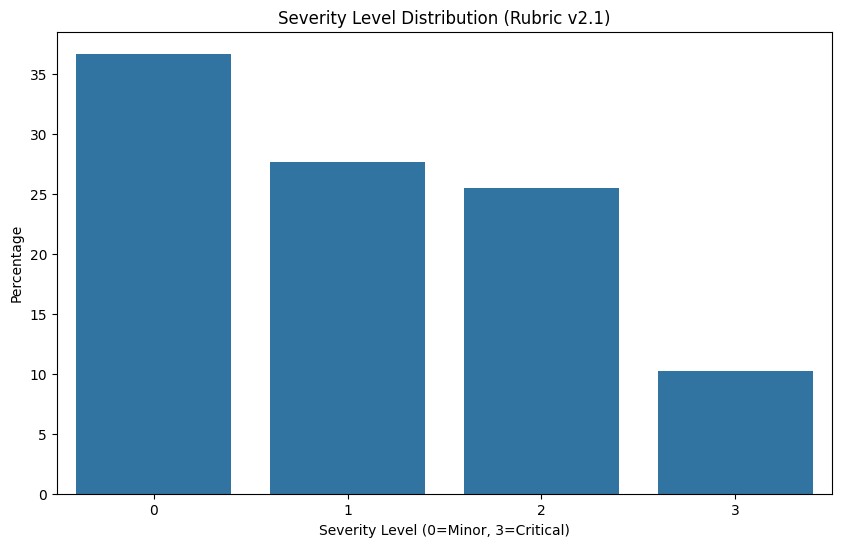

In [11]:
val = validate_severity_distribution(df)
print('Distribution (%):')
dist = df['severity_level'].value_counts(normalize=True).sort_index() * 100
print(dist)
print(f"\nValid: {val['is_valid']}")
for w in val['warnings']:
    print(f'  WARNING: {w}')

plt.figure(figsize=(10, 6))
sns.barplot(x=dist.index, y=dist.values)
plt.title('Severity Level Distribution (Rubric v2.1)')
plt.ylabel('Percentage')
plt.xlabel('Severity Level (0=Minor, 3=Critical)')
plt.show()

## 3. Face Validity Check

In [12]:
for level in range(4):
    subset = df[df['severity_level'] == level]
    print(f'\n--- LEVEL {level} (n={len(subset)}) ---')
    samples = subset.sample(min(3, len(subset)), random_state=42)
    for _, row in samples.iterrows():
        print(f"  ACN: {row.get('acn_num_ACN')}")
        print(f"  Result: {row.get('Events.5_Result')}")
        print(f"  Anomaly: {row.get('Events_Anomaly')}")
        print(f"  Synopsis: {str(row.get('Report 1.2_Synopsis'))[:200]}...")
        print()


--- LEVEL 0 (n=14170) ---
  ACN: 1675026
  Result: Air Traffic Control Issued Advisory / Alert; Flight Crew FLC complied w / Automation / Advisory
  Anomaly: ATC Issue All Types; Airspace Violation All Types; Deviation / Discrepancy - Procedural Published Material / Policy
  Synopsis: Small aircraft instructor reported ATC informed of Tower LOA traffic pattern altitude which is not published or available on pilot resources....

  ACN: 1282399
  Result: Flight Crew Became Reoriented
  Anomaly: Airspace Violation All Types; Deviation / Discrepancy - Procedural Published Material / Policy; Inflight Event / Encounter Weather / Turbulence
  Synopsis: Cessna P210 pilot reported an airspace incursion when he was preoccupied with a weather deviation....

  ACN: 1750780
  Result: 
  Anomaly: Aircraft Equipment Problem Less Severe; Deviation / Discrepancy - Procedural MEL / CDL; Deviation / Discrepancy - Procedural Published Material / Policy
  Synopsis: Air carrier First Officer reported a par

## 4. Save Targets

In [13]:
sev_path = resolve_path('data/processed/severity_targets.parquet')
sev_path.parent.mkdir(parents=True, exist_ok=True)
df[['acn_num_ACN', 'severity_level']].to_parquet(sev_path, index=False)
print(f'Targets saved to {sev_path}')

Targets saved to E:\OSFDA\data\processed\severity_targets.parquet
